<a href="https://colab.research.google.com/github/Haidermushtaq/Computer-Vision-/blob/main/Task_01_Skin_Cancer_ISIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skin Cancer Classification (ISIC 9 Classes)
**Task 01** — Transfer learning benchmark, deep-feature classifiers, and computational efficiency.

Haider Mushtaq (FA23-BAI-044)

**Before running:** Notebook settings → Accelerator = GPU, Internet = On. Add the dataset via *Add Input* → search `skin-cancer9-classesisic`.

In [5]:
# ==================== 0. INSTALL ====================
!pip install thop -q 2>/dev/null
print("done")

done


In [6]:
# ==================== 1. IMPORTS & CONFIG ====================
import os, time, copy, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
OUT = "/kaggle/working"

print("Device:", DEVICE)
print("Torch:", torch.__version__)

Device: cuda
Torch: 2.11.0+cu128


In [7]:
# ==================== 2. LOCATE DATASET ====================
# Searches /kaggle/input for the Train and Test folders automatically.

def find_split_dirs(base):
    train_dir = test_dir = None
    for dp, dn, fn in os.walk(base):
        name = os.path.basename(dp).lower()
        subdirs = [d for d in dn if not d.startswith(".")]
        if len(subdirs) >= 5:                       # folder full of class folders
            if name == "train" and train_dir is None:
                train_dir = dp
            elif name == "test" and test_dir is None:
                test_dir = dp
    return train_dir, test_dir

TRAIN_DIR, TEST_DIR = find_split_dirs("/kaggle/input")

# Fallback: download with kagglehub if not attached as input
if TRAIN_DIR is None or TEST_DIR is None:
    import kagglehub
    p = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")
    TRAIN_DIR, TEST_DIR = find_split_dirs(p)

assert TRAIN_DIR and TEST_DIR, "Dataset not found. Add it via 'Add Input' on the right panel."
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
TRAIN_DIR: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train
TEST_DIR : /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test


In [8]:
# ==================== 3. DATA PIPELINE ====================
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

base_ds = datasets.ImageFolder(TRAIN_DIR)
CLASSES = base_ds.classes
NUM_CLASSES = len(CLASSES)
labels = np.array([s[1] for s in base_ds.samples])

# stratified 85/15 split of Train -> train/val. Test folder untouched until the end.
train_idx, val_idx = train_test_split(np.arange(len(labels)), test_size=0.15,
                                      stratify=labels, random_state=SEED)

train_ds = Subset(datasets.ImageFolder(TRAIN_DIR, train_tf), train_idx)
val_ds   = Subset(datasets.ImageFolder(TRAIN_DIR, eval_tf),  val_idx)
test_ds  = datasets.ImageFolder(TEST_DIR, eval_tf)

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = make_loader(train_ds, True)
val_loader   = make_loader(val_ds,   False)
test_loader  = make_loader(test_ds,  False)

# class weights for the imbalanced dataset
counts = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
class_weights = torch.tensor(counts.sum() / (NUM_CLASSES * counts), dtype=torch.float32).to(DEVICE)

print(f"Classes ({NUM_CLASSES}):", CLASSES)
print(f"Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}")
print("\nTrain images per class:")
print(pd.Series(counts, index=CLASSES).to_string())

Classes (9): ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Train 1903 | Val 336 | Test 118

Train images per class:
actinic keratosis              97
basal cell carcinoma          320
dermatofibroma                 81
melanoma                      372
nevus                         303
pigmented benign keratosis    393
seborrheic keratosis           65
squamous cell carcinoma       154
vascular lesion               118


In [9]:
# ==================== 4. MODEL FACTORY & HELPERS ====================
def build_model(name, num_classes=NUM_CLASSES):
    if name == "AlexNet":
        m = models.alexnet(weights="IMAGENET1K_V1");        m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "VGG16":
        m = models.vgg16(weights="IMAGENET1K_V1");          m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "VGG19":
        m = models.vgg19(weights="IMAGENET1K_V1");          m.classifier[6] = nn.Linear(4096, num_classes)
    elif name == "ResNet18":
        m = models.resnet18(weights="IMAGENET1K_V1");       m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet50":
        m = models.resnet50(weights="IMAGENET1K_V1");       m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "ResNet101":
        m = models.resnet101(weights="IMAGENET1K_V1");      m.fc = nn.Linear(m.fc.in_features, num_classes)
    elif name == "DenseNet121":
        m = models.densenet121(weights="IMAGENET1K_V1");    m.classifier = nn.Linear(m.classifier.in_features, num_classes)
    elif name == "EfficientNet-B0":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1"); m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    else:
        raise ValueError(name)
    return m.to(DEVICE)

def strip_head(m, name):
    """Replace the final layer with Identity so the model outputs feature vectors."""
    if name in ("AlexNet", "VGG16", "VGG19"): m.classifier[6] = nn.Identity()
    elif name.startswith("ResNet"):           m.fc = nn.Identity()
    elif name == "DenseNet121":               m.classifier = nn.Identity()
    elif name == "EfficientNet-B0":           m.classifier[1] = nn.Identity()
    return m

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    tot_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        tot_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item(); n += y.size(0)
    return tot_loss / n, correct / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, ps, probs = [], [], []
    for x, y in loader:
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            out = model(x.to(DEVICE, non_blocking=True))
        prob = torch.softmax(out.float(), 1).cpu().numpy()
        ys.append(y.numpy()); ps.append(prob.argmax(1)); probs.append(prob)
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy (%)":  accuracy_score(y_true, y_pred) * 100,
        "Precision (%)": precision_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "Recall (%)":    recall_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "F1-Score (%)":  f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "AUC (%)":       roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro") * 100,
    }

print("helpers ready")

helpers ready


In [11]:
# ==================== 5. TRAIN ALL 8 CNNs  ->  TABLE 1 ====================
MODEL_NAMES = ["AlexNet", "VGG16", "VGG19", "ResNet18",
               "ResNet50", "ResNet101", "DenseNet121", "EfficientNet-B0"]

os.makedirs(OUT, exist_ok=True)

def run_model(name):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    model = build_model(name)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    best_val, best_state, t0 = -1.0, None, time.time()
    for ep in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        yv, pv, _ = evaluate(model, val_loader)
        val_acc = accuracy_score(yv, pv)
        scheduler.step()
        if val_acc > best_val:
            best_val, best_state = val_acc, copy.deepcopy(model.state_dict())
        print(f"  ep {ep:02d} | loss {tr_loss:.3f} | train {tr_acc*100:.1f}% | val {val_acc*100:.1f}%")

    model.load_state_dict(best_state)
    torch.save(best_state, f"{OUT}/{name}.pt")

    yt, pt, probt = evaluate(model, test_loader)
    m = compute_metrics(yt, pt, probt); m["Model"] = name
    print(f"  -> TEST acc {m['Accuracy (%)']:.2f}% | F1 {m['F1-Score (%)']:.2f}% | "
          f"AUC {m['AUC (%)']:.2f}% | {(time.time()-t0)/60:.1f} min")
    del model; torch.cuda.empty_cache()
    return m, (yt, pt, probt)

results, preds_store = [], {}
for name in MODEL_NAMES:
    m, p = run_model(name)
    results.append(m); preds_store[name] = p

table1 = pd.DataFrame(results)[["Model", "Accuracy (%)", "Precision (%)",
                                "Recall (%)", "F1-Score (%)", "AUC (%)"]].round(2)
table1.to_csv(f"{OUT}/table1.csv", index=False)
BEST_MODEL = table1.sort_values("Accuracy (%)", ascending=False).iloc[0]["Model"]

print("\n\n===== TABLE 1: Comparison of Transfer Learning Models =====")
print(table1.to_string(index=False))
print("\nBest model:", BEST_MODEL)


AlexNet
  ep 01 | loss 2.091 | train 27.5% | val 47.9%
  ep 02 | loss 1.709 | train 45.5% | val 43.2%
  ep 03 | loss 1.574 | train 52.4% | val 54.2%
  ep 04 | loss 1.470 | train 57.3% | val 54.2%
  ep 05 | loss 1.431 | train 58.7% | val 54.8%
  -> TEST acc 48.31% | F1 48.41% | AUC 88.29% | 3.1 min

VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 102MB/s]


  ep 01 | loss 2.176 | train 16.2% | val 38.1%
  ep 02 | loss 1.785 | train 37.5% | val 35.4%
  ep 03 | loss 1.618 | train 46.3% | val 42.3%
  ep 04 | loss 1.489 | train 54.0% | val 53.0%
  ep 05 | loss 1.400 | train 58.7% | val 52.1%
  -> TEST acc 53.39% | F1 55.73% | AUC 88.75% | 3.4 min

VGG19
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 124MB/s]


  ep 01 | loss 2.210 | train 18.3% | val 29.8%
  ep 02 | loss 1.898 | train 31.8% | val 32.4%
  ep 03 | loss 1.735 | train 39.0% | val 40.5%
  ep 04 | loss 1.576 | train 45.5% | val 45.5%
  ep 05 | loss 1.493 | train 49.8% | val 45.8%
  -> TEST acc 49.15% | F1 48.25% | AUC 88.16% | 3.5 min

ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


...

  ep 01 | loss 1.722 | train 43.3% | val 61.9%
  ep 02 | loss 1.433 | train 57.3% | val 61.0%
  ep 03 | loss 1.290 | train 65.6% | val 56.2%
  ep 04 | loss 1.181 | train 69.2% | val 58.9%
  ep 05 | loss 1.117 | train 72.5% | val 63.1%
  -> TEST acc 58.47% | F1 57.22% | AUC 92.24% | 3.2 min

DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 206MB/s]


  ep 01 | loss 1.921 | train 32.1% | val 51.8%
  ep 02 | loss 1.473 | train 57.6% | val 53.6%
  ep 03 | loss 1.330 | train 63.1% | val 56.8%
  ep 04 | loss 1.232 | train 67.7% | val 57.4%
  ep 05 | loss 1.193 | train 69.5% | val 59.8%
  -> TEST acc 59.32% | F1 60.09% | AUC 90.83% | 3.1 min

EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 197MB/s]


  ep 01 | loss 2.107 | train 35.0% | val 47.6%
  ep 02 | loss 1.702 | train 48.0% | val 53.6%
  ep 03 | loss 1.510 | train 55.2% | val 60.4%
  ep 04 | loss 1.409 | train 60.7% | val 62.2%
  ep 05 | loss 1.378 | train 60.9% | val 61.9%
  -> TEST acc 52.54% | F1 50.38% | AUC 88.43% | 3.5 min


===== TABLE 1: Comparison of Transfer Learning Models =====
          Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC (%)
        AlexNet         48.31          47.54       57.64         48.41    88.29
          VGG16         53.39          54.70       61.81         55.73    88.75
          VGG19         49.15          53.62       58.33         48.25    88.16
       ResNet18         56.78          54.17       58.56         54.20    89.96
       ResNet50         61.86          60.47       65.74         60.90    91.39
      ResNet101         58.47          54.96       62.96         57.22    92.24
    DenseNet121         59.32          61.34       63.66         60.09    90.83
Efficie

                            precision    recall  f1-score   support

         actinic keratosis       0.67      0.62      0.65        16
      basal cell carcinoma       0.70      0.88      0.78        16
            dermatofibroma       0.83      0.62      0.71        16
                  melanoma       0.14      0.06      0.09        16
                     nevus       0.52      1.00      0.68        16
pigmented benign keratosis       0.82      0.56      0.67        16
      seborrheic keratosis       0.40      0.67      0.50         3
   squamous cell carcinoma       0.62      0.50      0.55        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.62       118
                 macro avg       0.60      0.66      0.61       118
              weighted avg       0.61      0.62      0.59       118



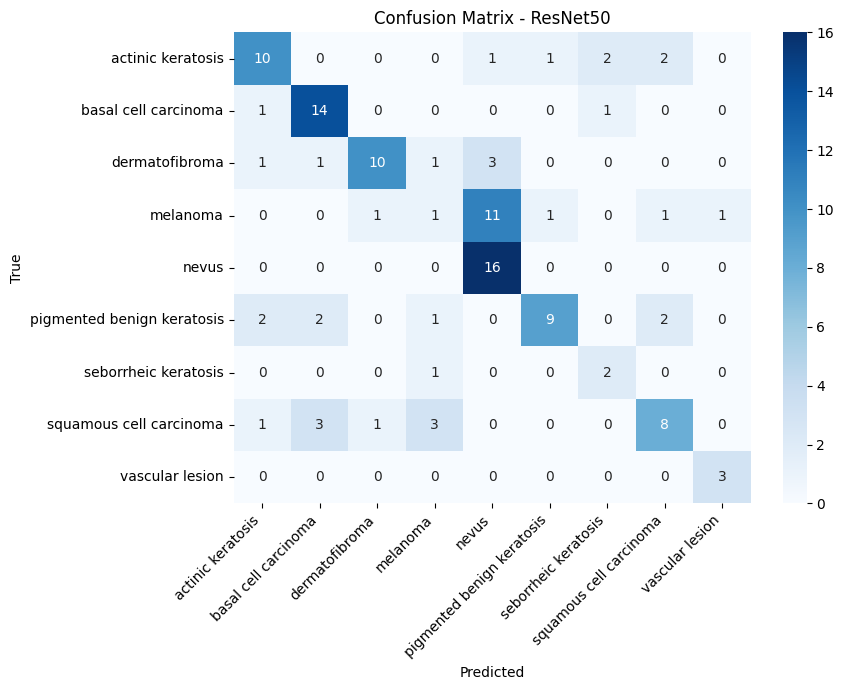

In [12]:
# ==================== 6. CONFUSION MATRIX (best model) ====================
yt, pt, _ = preds_store[BEST_MODEL]
print(classification_report(yt, pt, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(yt, pt)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Confusion Matrix - {BEST_MODEL}"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT}/confusion_matrix.png", dpi=150); plt.show()

In [13]:
# ==================== 7. DEEP FEATURES + CLASSIFIERS  ->  TABLE 2 ====================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

FEATURE_MODEL = BEST_MODEL
print("Feature extractor:", FEATURE_MODEL)

extractor = build_model(FEATURE_MODEL)
extractor.load_state_dict(torch.load(f"{OUT}/{FEATURE_MODEL}.pt", map_location=DEVICE))
extractor = strip_head(extractor, FEATURE_MODEL).eval()

@torch.no_grad()
def extract_features(model, loader):
    feats, ys = [], []
    for x, y in loader:
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            f = model(x.to(DEVICE, non_blocking=True))
        feats.append(f.float().cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(feats), np.concatenate(ys)

# no augmentation when extracting features (use eval transform on the train split)
train_feat_loader = make_loader(Subset(datasets.ImageFolder(TRAIN_DIR, eval_tf), train_idx), False)
X_train, y_train = extract_features(extractor, train_feat_loader)
X_test,  y_test  = extract_features(extractor, test_loader)
print("Feature dims:", X_train.shape[1])
del extractor; torch.cuda.empty_cache()

sc = StandardScaler().fit(X_train)
X_train_s, X_test_s = sc.transform(X_train), sc.transform(X_test)

classifiers = {
    "Logistic Regression":       (LogisticRegression(max_iter=3000, class_weight="balanced"), True),
    "Decision Tree":             (DecisionTreeClassifier(max_depth=20, class_weight="balanced", random_state=SEED), False),
    "Random Forest":             (RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED, n_jobs=-1), False),
    "K-Nearest Neighbors (KNN)": (KNeighborsClassifier(n_neighbors=5, n_jobs=-1), True),
    "Linear SVM":                (SVC(kernel="linear", C=1.0, probability=True, class_weight="balanced", random_state=SEED), True),
    "RBF-SVM":                   (SVC(kernel="rbf", C=10.0, gamma="scale", probability=True, class_weight="balanced", random_state=SEED), True),
    "XGBoost":                   (XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, subsample=0.8,
                                                colsample_bytree=0.8, tree_method="hist", eval_metric="mlogloss",
                                                random_state=SEED, n_jobs=-1), False),
}

rows = []
for cname, (clf, scaled) in classifiers.items():
    Xtr, Xte = (X_train_s, X_test_s) if scaled else (X_train, X_test)
    t0 = time.time()
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)
    m = compute_metrics(y_test, y_pred, y_prob)
    rows.append({"Feature Extractor": f"Deep Features ({FEATURE_MODEL})", "Classifier": cname, **m})
    print(f"{cname:26s} acc {m['Accuracy (%)']:.2f}%  F1 {m['F1-Score (%)']:.2f}%  ({time.time()-t0:.1f}s)")

table2 = pd.DataFrame(rows).round(2)
table2.to_csv(f"{OUT}/table2.csv", index=False)
print("\n\n===== TABLE 2: Comparison of Different Classifiers =====")
print(table2.to_string(index=False))

Feature extractor: ResNet50
Feature dims: 2048
Logistic Regression        acc 60.17%  F1 56.52%  (15.3s)
Decision Tree              acc 53.39%  F1 50.03%  (6.0s)
Random Forest              acc 55.93%  F1 51.23%  (22.4s)
K-Nearest Neighbors (KNN)  acc 59.32%  F1 53.98%  (0.1s)
Linear SVM                 acc 61.86%  F1 57.66%  (4.1s)
RBF-SVM                    acc 59.32%  F1 55.30%  (10.1s)
XGBoost                    acc 56.78%  F1 53.13%  (424.0s)


===== TABLE 2: Comparison of Different Classifiers =====
       Feature Extractor                Classifier  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC (%)
Deep Features (ResNet50)       Logistic Regression         60.17          65.08       58.33         56.52    91.38
Deep Features (ResNet50)             Decision Tree         53.39          60.87       52.78         50.03    73.38
Deep Features (ResNet50)             Random Forest         55.93          63.28       54.86         51.23    92.44
Deep Features (ResNet50) K-Nea

In [14]:
# ==================== 8. COMPUTATIONAL EFFICIENCY  ->  TABLE 3 ====================
try:
    from thop import profile as thop_profile
    HAVE_THOP = True
except ImportError:
    HAVE_THOP = False
    print("thop missing -> FLOPs will be NaN. Run cell 0 with Internet on.")

def count_params(m):  return sum(p.numel() for p in m.parameters()) / 1e6
def model_size_mb(m): return (sum(p.numel() for p in m.parameters()) + sum(b.numel() for b in m.buffers())) * 4 / 1024**2

def count_flops(m):
    if not HAVE_THOP: return float("nan")
    macs, _ = thop_profile(copy.deepcopy(m), inputs=(torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE),), verbose=False)
    return macs * 2 / 1e9                     # thop gives MACs; FLOPs = 2 * MACs

@torch.no_grad()
def inference_ms(m, runs=100, warmup=20):
    m.eval(); x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    for _ in range(warmup): m(x)
    if DEVICE == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(runs): m(x)
    if DEVICE == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / runs * 1000

EFF_MODELS = ["AlexNet", "VGG16", "VGG19", "ResNet18", "ResNet50", "DenseNet121", "EfficientNet-B0"]
acc_lookup = dict(zip(table1["Model"], table1["Accuracy (%)"]))

rows = []
for name in EFF_MODELS:
    m = build_model(name)
    m.load_state_dict(torch.load(f"{OUT}/{name}.pt", map_location=DEVICE))
    rows.append({
        "Model": name,
        "Parameters (M)":      round(count_params(m), 2),
        "Model Size (MB)":     round(model_size_mb(m), 2),
        "FLOPs (G)":           round(count_flops(m), 2),
        "Inference Time (ms)": round(inference_ms(m), 2),
        "Accuracy (%)":        acc_lookup[name],
    })
    del m; torch.cuda.empty_cache()
    print(name, "done")

table3 = pd.DataFrame(rows)
table3.to_csv(f"{OUT}/table3.csv", index=False)
print("\n\n===== TABLE 3: Computational Efficiency Comparison =====")
print(table3.to_string(index=False))
print(f"\n(inference: {DEVICE.upper()}, batch 1, mean of 100 runs after 20 warmup)")

AlexNet done
VGG16 done
VGG19 done
ResNet18 done
ResNet50 done
DenseNet121 done
EfficientNet-B0 done


===== TABLE 3: Computational Efficiency Comparison =====
          Model  Parameters (M)  Model Size (MB)  FLOPs (G)  Inference Time (ms)  Accuracy (%)
        AlexNet           57.04           217.59       1.42                 1.88         48.31
          VGG16          134.30           512.30      30.93                 8.93         53.39
          VGG19          139.61           532.56      39.26                10.83         49.15
       ResNet18           11.18            42.69       3.65                 2.25         56.78
       ResNet50           23.53            89.95       8.26                 5.77         61.86
    DenseNet121            6.96            26.88       5.79                20.57         59.32
EfficientNet-B0            4.02            15.49       0.83                 7.70         52.54

(inference: CUDA, batch 1, mean of 100 runs after 20 warmup)


In [15]:
# ==================== 9. FINAL SUMMARY ====================
print("TABLE 1\n", table1.to_string(index=False), "\n")
print("TABLE 2\n", table2.to_string(index=False), "\n")
print("TABLE 3\n", table3.to_string(index=False), "\n")
print("CSVs saved in /kaggle/working  ->  table1.csv, table2.csv, table3.csv")

TABLE 1
           Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC (%)
        AlexNet         48.31          47.54       57.64         48.41    88.29
          VGG16         53.39          54.70       61.81         55.73    88.75
          VGG19         49.15          53.62       58.33         48.25    88.16
       ResNet18         56.78          54.17       58.56         54.20    89.96
       ResNet50         61.86          60.47       65.74         60.90    91.39
      ResNet101         58.47          54.96       62.96         57.22    92.24
    DenseNet121         59.32          61.34       63.66         60.09    90.83
EfficientNet-B0         52.54          51.18       55.09         50.38    88.43 

TABLE 2
        Feature Extractor                Classifier  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  AUC (%)
Deep Features (ResNet50)       Logistic Regression         60.17          65.08       58.33         56.52    91.38
Deep Features (ResNet50)      